In [38]:
import lowresource_llm_evaluation.exploreResults as explore
import lowresource_llm_evaluation.constants.aesthetics as aesthetics 

raw_base = "./results/Raw/"
raw_lora = "./results_lora/Raw/"
salida_base = "./results/Processed/"
salida_lora = "./results_lora/Processed/"
figures_base = "./results/Figures/"
figures_lora = "./results_lora/Figures/"

idiomas = [ "asturiano", "aranes", "gallego"]

In [39]:
explore.pretty_print_results(explore.load_results(raw_base + "aranes/resultados_aranes_Mistral-7B-Instruct-v0.3_05-10_20-28-27.json"))


      RESULTADOS DEL MODELO



########################################
### TAREA: CALIDAD_LENGUA
########################################

▶ MÉTRICAS GLOBALES

Métrica          Valor
---------------  -----------------------------------------------------
ttr              0.4681802796379446
entropy          6.8886785153068555
ngram_overlap    0.0
freq_target      0.4698188801536519
freq_comparison  {'es': 0.4670386513003484, 'fr': 0.30053548526423357}
calidad          0.17817821296635833


▶ EJEMPLOS


--- Ejemplo 1 ---
text: En els primers temps de la seva existència, l'Aragon era una terra desolada i salvatge, habitada per uns primitius homes nòmades, coneguts com els Aragonesos. Aquestos gentils home...
ttr: 0.47306791569086654
entropy: 6.908985512841516
ngram_overlap: 0.0
freq_target: 0.48009367681498827
freq_comparison: {'es': 0.47540983606557374, 'fr': 0.3255269320843091}
calidad: 0.18066158847216107
---------------------------


########################################
### TAREA

### Resultados modelos base

In [40]:

resultados_base = {
"aranes":{
    "Gemma 7B": explore.load_results(raw_base + "aranes/resultados_aranes_gemma-7b-it_05-10_22-05-37.json"),
    "Mistral 7B": explore.load_results(raw_base + "aranes/resultados_aranes_Mistral-7B-Instruct-v0.3_05-10_20-28-27.json"),
    "Qwen2.5 7B": explore.load_results(raw_base + "aranes/resultados_aranes_Qwen2.5-7B-Instruct_05-10_22-57-01.json"),
    "Salamandra 7B": explore.load_results(raw_base + "aranes/resultados_aranes_salamandra-7b-instruct_05-10_20-50-02.json"),
}, 
"asturiano": {
    "Gemma 7B": explore.load_results(raw_base + "asturiano/resultados_asturiano_gemma-7b-it_05-11_07-54-56.json"),
    "Mistral 7B": explore.load_results(raw_base + "asturiano/resultados_asturiano_Mistral-7B-Instruct-v0.3_05-10_23-51-44.json"),
    "Qwen2.5 7B": explore.load_results(raw_base + "asturiano/resultados_asturiano_Qwen2.5-7B-Instruct_05-11_08-41-23.json"),
    "Salamandra 7B": explore.load_results(raw_base + "asturiano/resultados_asturiano_salamandra-7b-instruct_05-11_00-53-38.json"),
},
"gallego":{
    "Gemma 7B": explore.load_results(raw_base + "gallego/resultados_gallego_gemma-7b-it_05-11_12-04-22.json"),
    "Mistral 7B": explore.load_results(raw_base + "gallego/resultados_gallego_Mistral-7B-Instruct-v0.3_05-11_09-34-03.json"),
    "Qwen2.5 7B": explore.load_results(raw_base + "gallego/resultados_gallego_Qwen2.5-7B-Instruct_05-11_20-17-43.json"),
    "Salamandra 7B": explore.load_results(raw_base + "gallego/resultados_gallego_salamandra-7b-instruct_05-11_10-48-06.json"),
}
}

In [41]:
explore.generate_html_report(resultados_base["aranes"], salida_base + "aranes_resultados_base.html")

explore.generate_html_report(resultados_base["asturiano"], salida_base + "asturiano_resultados_base.html")

explore.generate_html_report(resultados_base["gallego"], salida_base + "gallego_resultados_base.html")

HTML generado en: ./results/Processed/aranes_resultados_base.html
HTML generado en: ./results/Processed/asturiano_resultados_base.html
HTML generado en: ./results/Processed/gallego_resultados_base.html


In [42]:


explore.generate_latex_snippet_compacto(resultados_base["aranes"], lengua="Aranés", output_path= salida_base + "aranes_resultados_base.tex")

explore.generate_latex_snippet_compacto(resultados_base["asturiano"], lengua="Asturiano", output_path= salida_base + "asturiano_resultados_base.tex")

explore.generate_latex_snippet_compacto(resultados_base["gallego"], lengua="Gallego", output_path= salida_base + "gallego_resultados_base.tex")
explore.merge_latex_files([salida_base + lang + "_resultados_base.tex" for lang in idiomas], 
                  salida_base + "resultados_base.tex", "Resultados de los modelos base")

Éxito: Archivo consolidado creado en ./results/Processed/resultados_base.tex


## Resultados QLoRA

In [43]:

resultados_qlora = {
    "asturiano":{
    "Base": explore.load_results(raw_base + "asturiano/resultados_asturiano_Qwen2.5-7B-Instruct_05-11_08-41-23.json"),
    "Entrenado": explore.load_results(raw_lora + "asturiano/resultados_QLORA_asturiano_modelo3200SinConcatenar_05-21_21-02-27.json"),
    "Concatenado": explore.load_results(raw_lora + "asturiano/resultados_QLORA_asturiano_37500-asturiano-concatenado_05-21_20-00-48.json"),
    "Concatenado + Inst": explore.load_results(raw_lora + "asturiano/resultados_QLORA_asturiano_39000-asturiano-concatenado-Instructivo_05-21_20-36-47.json"),
},
"aranes":{
    "Base": explore.load_results(raw_base + "aranes/resultados_aranes_Qwen2.5-7B-Instruct_05-10_22-57-01.json"),
    "Entrenado": explore.load_results(raw_lora + "aranes/resultados_QLORA_aranes_31000.json"),
    "Entrenado + Inst": explore.load_results(raw_lora + "aranes/resultados_QLORA_aranes_31000+2000_Instructivo.json"),
    },
"gallego":{
    "Base": explore.load_results(raw_base + "gallego/resultados_gallego_Qwen2.5-7B-Instruct_05-11_20-17-43.json"),
    "Entrenado": explore.load_results(raw_lora + "gallego/resultados_QLORA_gallego_checkpoint-30000_05-27_16-48-36.json"),
    },
}


In [44]:
explore.generate_html_report({
    "Qwen2.5 7B": explore.load_results(raw_base + "asturiano/resultados_asturiano_Qwen2.5-7B-Instruct_05-11_08-41-23.json"),
    "Concatenated 37500": explore.load_results(raw_lora + "asturiano/resultados_QLORA_asturiano_37500-asturiano-concatenado_05-21_20-00-48.json"),
    "37500 + Instructivo": explore.load_results(raw_lora + "asturiano/resultados_QLORA_asturiano_39000-asturiano-concatenado-Instructivo_05-21_20-36-47.json"),
    "Not Concatenated 32000": explore.load_results(raw_lora + "asturiano/resultados_QLORA_asturiano_modelo3200SinConcatenar_05-21_21-02-27.json"),
    "32000 + Instructivo": explore.load_results(raw_lora + "asturiano/resultados_QLORA_asturiano_modelo3500SinConcatenar-Instructivo_05-21_21-27-42.json"),
}, output_path= salida_lora + "asturiano_resultados_qlora.html")

explore.generate_html_report(resultados_base["aranes"], salida_lora + "aranes_resultados_qlora.html")

explore.generate_html_report(resultados_base["gallego"], salida_lora + "gallego_resultados_qlora.html")

HTML generado en: ./results_lora/Processed/asturiano_resultados_qlora.html
HTML generado en: ./results_lora/Processed/aranes_resultados_qlora.html
HTML generado en: ./results_lora/Processed/gallego_resultados_qlora.html


In [45]:
explore.generate_latex_snippet_compacto(resultados_qlora["asturiano"], lengua="Asturiano QLoRA", output_path= salida_lora + "asturiano_resultados_qlora.tex")
explore.generate_latex_snippet_compacto(resultados_qlora["aranes"], lengua="Aranés QLoRA", output_path= salida_lora + "aranes_resultados_qlora.tex")
explore.generate_latex_snippet_compacto(resultados_qlora["gallego"], lengua="Gallego QLoRA", output_path= salida_lora + "gallego_resultados_qlora.tex")

explore.merge_latex_files([salida_lora + lang + "_resultados_qlora.tex" for lang in idiomas], 
                  salida_lora + "resultados_qlora.tex", "Resultados de los modelos entrenados")

Éxito: Archivo consolidado creado en ./results_lora/Processed/resultados_qlora.tex


In [46]:
explore.explorar_estructuras(explore.load_results(raw_base + "/asturiano/resultados_asturiano_Qwen2.5-7B-Instruct_05-11_08-41-23.json"))

=== MAPA DE TAREAS Y MÉTRICAS DISPONIBLES ===

Tarea: 'calidad_lengua'
    ├── 'ttr'
    ├── 'entropy'
    ├── 'ngram_overlap'
    ├── 'freq_target'
    ├── 'freq_comparison' -> Requiere sub-métrica: ['fr', 'es']
    ├── 'calidad'

Tarea: 'traduccion'
    ├── 'BLEU'
    ├── 'chrF'

Tarea: 'round_trip'
    ├── 'BLEU'
    ├── 'chrF'

Tarea: 'vocabulario'
    ├── 'accuracy'
    ├── 'accuracy_lower'
    ├── 'levenshtein'

Tarea: 'ortografia'
    ├── 'BLEU'
    ├── 'chrF'
    ├── 'Levenshtein'
    ├── 'precision'
    ├── 'recall'
    ├── 'F1'
    ├── 'errores_totales'
    ├── 'errores_corregidos'
    ├── 'errores_no_corregidos'
    ├── 'errores_nuevos'



In [47]:
def calcular_indice_competencia_global(tareas_dict):
    scores = []
    
    # 1. Pilar Traducción: Usamos BLEU (viene en escala 0-100 en tu JSON, ej: 6.65)
    bleu = tareas_dict.get("traduccion", {}).get("media", {}).get("BLEU")
    if isinstance(bleu, (int, float)):
        scores.append(bleu)
        
    # 2. Pilar Ortografía: Usamos F1 (en tu JSON viene como "F1", ej: 0.2301)
    # Como viene en escala 0-1, lo multiplicamos por 100 para unificar escalas
    f1_gramatica = tareas_dict.get("ortografia", {}).get("media", {}).get("F1")
    if isinstance(f1_gramatica, (int, float)):
        if f1_gramatica <= 1.0: 
            f1_gramatica *= 100
        scores.append(f1_gramatica)
        
    # 3. Pilar Vocabulario: Usamos accuracy_lower (en tu JSON viene como "accuracy_lower", ej: 0.0)
    # Si viene en formato 0-1, lo pasamos a base 100
    acc_vocab = tareas_dict.get("vocabulario", {}).get("media", {}).get("accuracy_lower")
    if isinstance(acc_vocab, (int, float)):
        if acc_vocab <= 1.0:
            acc_vocab *= 100
        scores.append(acc_vocab)
        
    # Devolvemos la media de las tres tareas si tenemos datos
    return sum(scores) / len(scores) if scores else None

def calcular_indice_competencia_avanzado(tareas_dict):
    scores = []
    
    # 1. Pilar Traducción: BLEU (0 a 100)
    bleu = tareas_dict.get("traduccion", {}).get("media", {}).get("BLEU")
    if isinstance(bleu, (int, float)):
        scores.append(bleu)
        
    # 2. Pilar Vocabulario: Accuracy Lower (Pasado a base 100)
    acc_vocab = tareas_dict.get("vocabulario", {}).get("media", {}).get("accuracy_lower")
    if isinstance(acc_vocab, (int, float)):
        if acc_vocab <= 1.0:
            acc_vocab *= 100
        scores.append(acc_vocab)
        
    # 3. Nuevo Pilar Ortografía: Índice de No-Degradación (Base 100)
    # Evaluamos cuántos "errores nuevos" mete por cada frase en comparación con una base
    orto_media = tareas_dict.get("ortografia", {}).get("media", {})
    err_nuevos = orto_media.get("errores_nuevos")
    
    if isinstance(err_nuevos, (int, float)):
        # Diseño de la métrica: Empezamos en 100 puntos (perfección). 
        # Restamos una penalización por cada error nuevo que el modelo introduce.
        # Puedes multiplicar 'err_nuevos' por un factor (ej: * 10) si quieres penalizar más duro.
        score_ortografia = max(0, 100 - (err_nuevos * 10)) 
        scores.append(score_ortografia)
    
    return sum(scores) / len(scores) if scores else None

In [48]:
import math

def indice(tareas_dict):
    scores = []
    
    # ==========================================
    # PILAR 1: TRADUCCIÓN DIRECTA (Magnitud 0-100)
    # ==========================================
    chrf = tareas_dict.get("traduccion", {}).get("media", {}).get("chrF")
    if isinstance(chrf, (int, float)):
        scores.append(chrf)
        
    # ==========================================
    # PILAR 2: ROUND-TRIP TRANSLATION (Magnitud 0-100)
    # ==========================================
    chrf_rt = tareas_dict.get("round_trip", {}).get("media", {}).get("chrF")
    if isinstance(chrf_rt, (int, float)):
        scores.append(chrf_rt)
        
    # ==========================================
    # PILAR 3: VOCABULARIO (Magnitud 0-100 con BOOSTER)
    # ==========================================
    acc_vocab = tareas_dict.get("vocabulario", {}).get("media", {}).get("accuracy_lower")
    if isinstance(acc_vocab, (int, float)):
        # Si ya viene en base 100 (mayor a 1.0), lo normalizamos temporalmente a base 1
        if acc_vocab > 1.0:
            acc_vocab /= 100.0
            
        # Aplicamos el Booster no lineal (Raíz cuadrada) para rescatar valores bajos
        acc_vocab_boosted = math.sqrt(acc_vocab) * 100
        scores.append(acc_vocab_boosted)
        
    # ==========================================
    # PILAR 4: ORTOGRAFÍA (Rango 0 a 100 calibrado con Lambda)
    # ==========================================
    orto_media = tareas_dict.get("ortografia", {}).get("media", {})
    
    if "errores_nuevos" in orto_media:
        err_totales = orto_media.get("errores_totales", 0)
        err_corregidos = orto_media.get("errores_corregidos", 0)
        err_nuevos = orto_media.get("errores_nuevos", 0)
        chrf_ort = orto_media.get("chrF", 100) # Usamos el chrF de la tarea de ortografía
        
        # 1. Porcentaje base de éxito de reparación
        if err_totales > 0:
            nota_reparacion = (err_corregidos / err_totales) * 100
        else:
            nota_reparacion = 100.0
            
        # 2. Penalizaciones: Errores nuevos directos y AntichrF suavizado por Lambda
        lambda_suavizado = 0.3
        penalizacion_calidad = lambda_suavizado * (100 - chrf_ort)
        
        # Combinación de la puntuación neta
        score_orto = nota_reparacion - err_nuevos - penalizacion_calidad
        
        # Acotamos estrictamente entre 0 y 100
        score_orto = max(0, min(100, score_orto))
        scores.append(score_orto)
        print(f"Score Ortografía: {score_orto:.2f}")

    # ==========================================
    # PROMEDIO FINAL
    # ==========================================
    return sum(scores) / len(scores) if scores else None

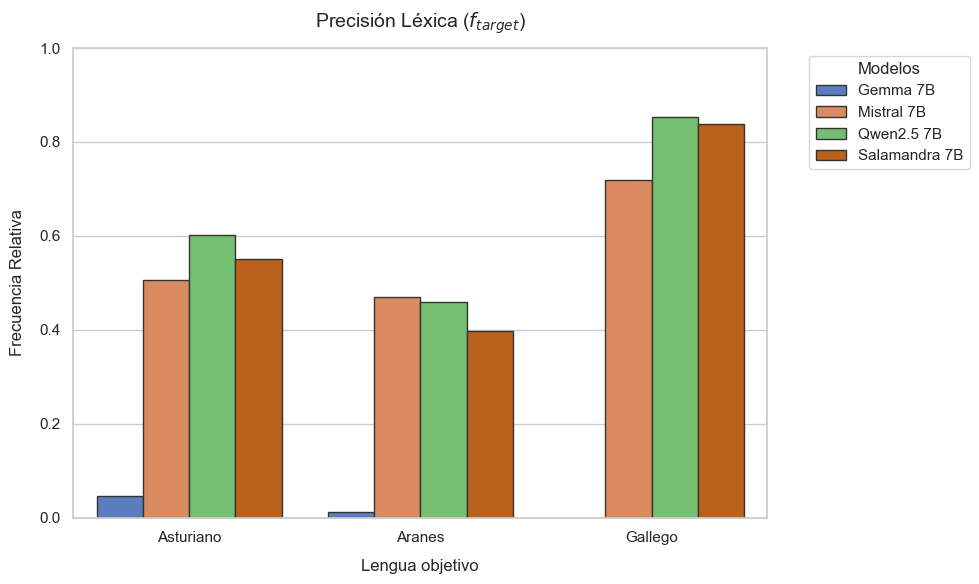

Score Ortografía: 1.25
Score Ortografía: 36.33
Score Ortografía: 17.70
Score Ortografía: 54.50
Score Ortografía: 10.08
Score Ortografía: 31.16
Score Ortografía: 19.20
Score Ortografía: 53.36
Score Ortografía: 13.89
Score Ortografía: 43.51
Score Ortografía: 37.53
Score Ortografía: 66.25


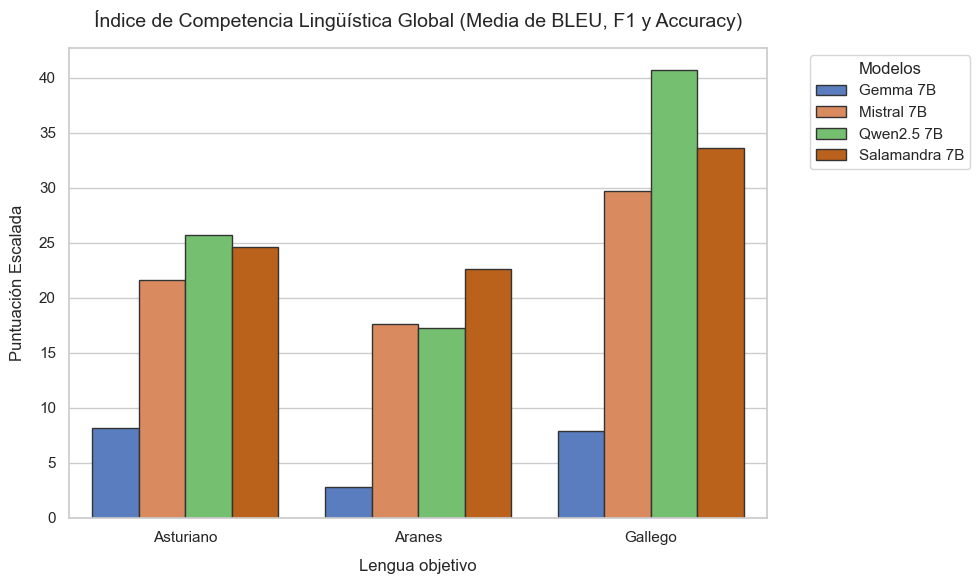

In [49]:
explore.generar_grafico_barras(
    datos_globales=resultados_base,
    extractor="freq_target",
    titulo="Precisión Léxica ($f_{target}$)",
    ylabel="Frecuencia Relativa",
    ylim=(0, 1.0),                 
    idiomas_orden=idiomas,    
    output_path=figures_base + "Calidad_freq_target_base.png",
    motor=aesthetics.SEABORN
)


explore.generar_grafico_barras(
    datos_globales=resultados_base,
    extractor=indice,
    titulo="Índice de Competencia Lingüística Global (Media de BLEU, F1 y Accuracy)",
    ylabel="Puntuación Escalada",
    ylim=(0, None),                  
    idiomas_orden=idiomas,     
    output_path=figures_base + "IndiceMetricas_base.png",
    motor=aesthetics.SEABORN
)

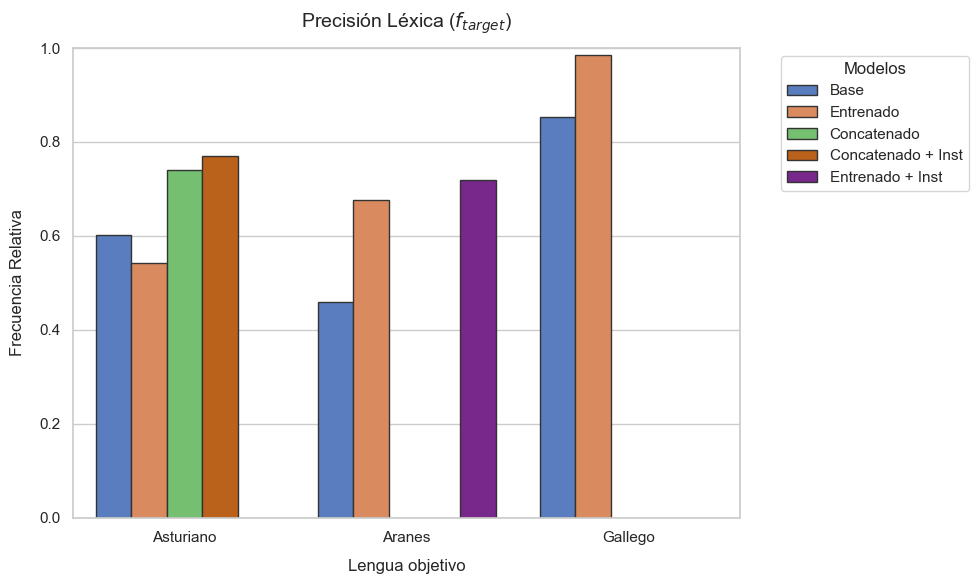

Score Ortografía: 19.20
Score Ortografía: 39.55
Score Ortografía: 55.82
Score Ortografía: 58.88
Score Ortografía: 17.70
Score Ortografía: 58.20
Score Ortografía: 56.48
Score Ortografía: 37.53
Score Ortografía: 43.27


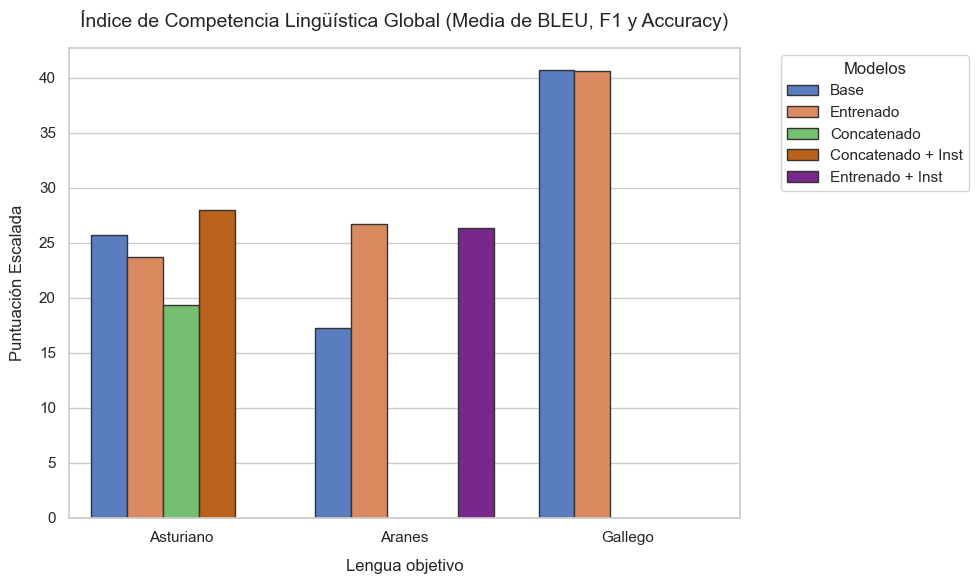

In [50]:
explore.generar_grafico_barras(
    datos_globales=resultados_qlora,
    extractor="freq_target",
    titulo="Precisión Léxica ($f_{target}$)",
    ylabel="Frecuencia Relativa",
    ylim=(0, 1.0),                 
    idiomas_orden=idiomas,    
    output_path= figures_lora + "Calidad_freq_target_qlora.png",
    motor=aesthetics.SEABORN
)


explore.generar_grafico_barras(
    datos_globales=resultados_qlora,
    extractor=indice,
    titulo="Índice de Competencia Lingüística Global (Media de BLEU, F1 y Accuracy)",
    ylabel="Puntuación Escalada",
    ylim=(0, None),                  
    idiomas_orden=idiomas,     
    output_path= figures_lora + "IndiceMetricas_qlora.png",
    motor=aesthetics.SEABORN
)

In [51]:
# Gráfica 1: Tu métrica nuclear directa
explore.generar_grafico_barras(
    datos_globales=resultados_base,
    extractor="freq_target",
    titulo="Precisión Léxica (f_target)",
    ylabel="Frecuencia Relativa",
    ylim=(0, 1.0),
    idiomas_orden=idiomas,
    output_path= None,
    motor=aesthetics.PLOTLY
)

# Gráfica 2: El nuevo índice refinado con penalización por errores nuevos
explore.generar_grafico_barras(
    datos_globales=resultados_base,
    extractor=indice,
    titulo="Índice de Competencia Lingüística Avanzado (Penalizando Degradación Ortográfica)",
    ylabel="Puntuación Escalada (0 - 100)",
    ylim=(0, 100),
    idiomas_orden=idiomas,
    output_path= None,
    motor=aesthetics.PLOTLY
)

Score Ortografía: 1.25
Score Ortografía: 36.33
Score Ortografía: 17.70
Score Ortografía: 54.50
Score Ortografía: 10.08
Score Ortografía: 31.16
Score Ortografía: 19.20
Score Ortografía: 53.36
Score Ortografía: 13.89
Score Ortografía: 43.51
Score Ortografía: 37.53
Score Ortografía: 66.25


In [52]:
idiomas = ["asturiano", "aranes", "gallego"]

# Gráfica 1: Tu métrica nuclear directa
explore.generar_grafico_barras(
    datos_globales=resultados_qlora,
    extractor="freq_target",
    titulo="Precisión Léxica (f_target)",
    ylabel="Frecuencia Relativa",
    ylim=(0, 1.0),
    idiomas_orden=idiomas,
    output_path= None,
    motor=aesthetics.PLOTLY
)

# Gráfica 2: El nuevo índice refinado con penalización por errores nuevos
explore.generar_grafico_barras(
    datos_globales=resultados_qlora,
    extractor=indice,
    titulo="Índice de Competencia Lingüística Avanzado (Penalizando Degradación Ortográfica)",
    ylabel="Puntuación Escalada (0 - 100)",
    ylim=(0, 100),
    idiomas_orden=idiomas,
    output_path= None,
    motor=explore.PLOTLY
)

Score Ortografía: 19.20
Score Ortografía: 39.55
Score Ortografía: 55.82
Score Ortografía: 58.88
Score Ortografía: 17.70
Score Ortografía: 58.20
Score Ortografía: 56.48
Score Ortografía: 37.53
Score Ortografía: 43.27


In [1]:
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def cargar_y_filtrar_cada_1000(lista_carpetas):
    datos_consolidados = []
    
    for carpeta in lista_carpetas:
        ruta_json = os.path.join(carpeta, "trainer_state.json")
        
        if not os.path.exists(ruta_json):
            print(f"⚠️ Advertencia: No se encontró 'trainer_state.json' en: {carpeta}")
            continue
            
        print(f"📖 Procesando y alineando logs de: {carpeta}")
        with open(ruta_json, "r", encoding="utf-8") as f:
            estado = json.load(f)
            
        historial = estado.get("log_history", [])
        
        # Extraemos solo los registros válidos con loss y step
        registros_limpios = [e for e in historial if "loss" in e and "step" in e]
        if not registros_limpios:
            continue
            
        # Determinamos el paso máximo de este experimento
        max_step = max(e["step"] for e in registros_limpios)
        
        # Creamos los objetivos que queremos buscar obligatoriamente: 1000, 2000, 3000...
        pasos_objetivo = np.arange(1000, max_step + 1, 1000)
        
        # Para cada múltiplo de 1000, buscamos el registro con el step más cercano
        for objetivo in pasos_objetivo:
            # Encontramos el registro cuya diferencia con el 'objetivo' sea la mínima
            mejor_registro = min(registros_limpios, key=lambda x: abs(x["step"] - objetivo))
            
            # Control de seguridad: Si el "más cercano" está ridículamente lejos (ej. a más de 500 pasos), lo ignoramos
            if abs(mejor_registro["step"] - objetivo) < 500:
                datos_consolidados.append({
                    "Experimento": os.path.basename(os.path.normpath(carpeta)),
                    "Step": objetivo,  # Forzamos el eje X al múltiplo de 1000 exacto para que se alineen perfectamente
                    "Loss": mejor_registro["loss"]
                })
                
    if not datos_consolidados:
        raise ValueError("❌ No se pudieron consolidar pasos alineados cada 1000.")
        
    return pd.DataFrame(datos_consolidados)

def graficar_loss_alineada(df, guardar_como="comparativa_loss_exacta.png"):
    # Configuración del tema visual limpio
    sns.set_theme(style="whitegrid", rc={"grid.linestyle": "--", "grid.alpha": 0.6})
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Dibujamos las líneas. Ahora el eje X son pasos reales de 1000 en 1000
    sns.lineplot(
        data=df,
        x="Step",
        y="Loss",
        hue="Experimento",
        linewidth=2,
        marker="o",  # Ponemos un puntito en cada 1000 para ver la coincidencia exacta
        markersize=4,
        alpha=0.85,
        ax=ax
    )
    
    # Ajustes estéticos de la gráfica
    ax.set_title("Pérdida de Entrenamiento", fontsize=14, fontweight="bold", pad=15)
    ax.set_xlabel("Pasos de Entrenamiento", fontsize=11, labelpad=10)
    ax.set_ylabel("Pérdida ($Loss$)", fontsize=11, labelpad=10)
    
    # Leyenda fuera a la derecha
    ax.legend(
        title="Experimentos", 
        title_fontsize="11", 
        fontsize="9", 
        loc="upper left", 
        bbox_to_anchor=(1.02, 1), 
        borderaxespad=0.,
        frameon=True
    )
    
    plt.savefig(guardar_como, dpi=300, bbox_inches="tight")
    print(f"Gráfico Guardado como: {guardar_como}")


📖 Procesando y alineando logs de: 32000-asturiano-SinConcatenar
📖 Procesando y alineando logs de: 39000-asturiano-concatenado-instructivo
📖 Procesando y alineando logs de: 37500-asturiano-concatenado
📖 Procesando y alineando logs de: 33000-aranes-instructivo
📖 Procesando y alineando logs de: 31000-aranes
📖 Procesando y alineando logs de: 30000-gallego
Gráfico Guardado como: comparativa_entrenamiento_1000_steps.png


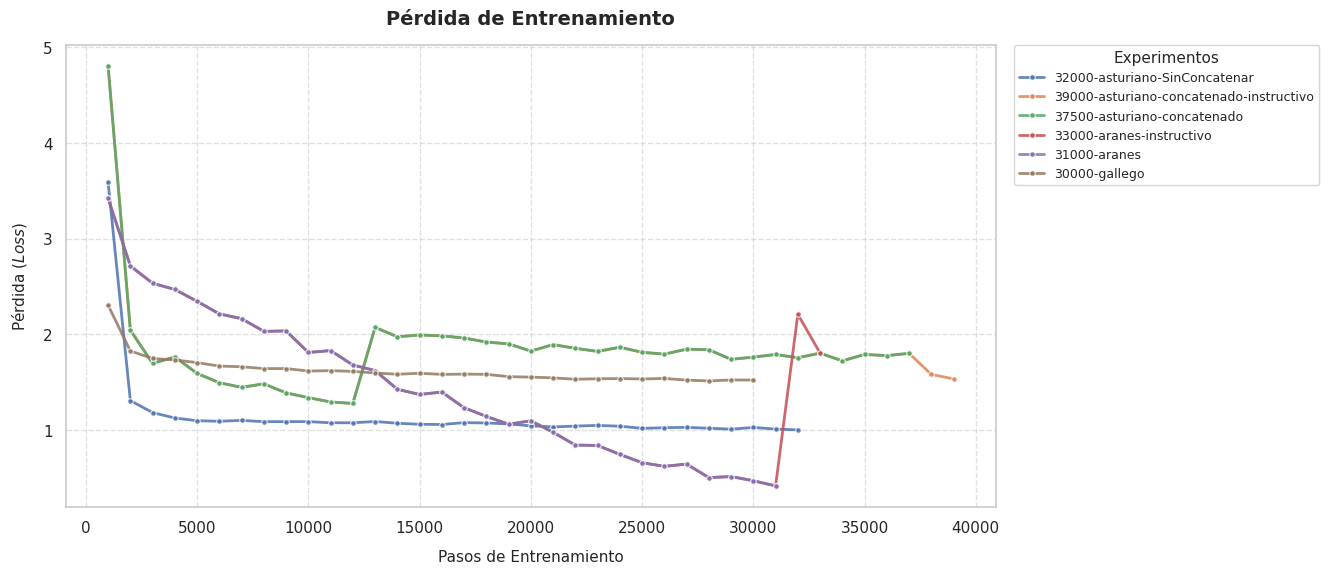

In [4]:
# =====================================================================
# CONFIGURACIÓN MANUAL: Rutas de tus ejecuciones de entrenamiento
# =====================================================================
mis_carpetas = [
    "32000-asturiano-SinConcatenar",
    "39000-asturiano-concatenado-instructivo",
    "37500-asturiano-concatenado",
    "33000-aranes-instructivo",
    "31000-aranes",
    "30000-gallego"
]


# 1. Cargar datos aplicando el filtro de cercanía a múltiplos de 1000
df_fijo = cargar_y_filtrar_cada_1000(mis_carpetas)

# 2. Generar el gráfico con las líneas perfectamente emparejadas en el eje X
graficar_loss_alineada(df_fijo, guardar_como="comparativa_entrenamiento_1000_steps.png")
        